In [2]:
# Load data
import pandas as pd

quotation_data_path = r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data.xlsx"
# Date_Columns = ["Due_Date", "Date_Sent"]

# This creates: {"Due_Date": str, "Date_Sent": str}
# dtype_mapping = {col: str for col in Date_Columns}

# quotation_data_df = pd.read_excel(quotation_data_path, dtype=dtype_mapping)
quotation_data_df = pd.read_excel(quotation_data_path)
#quotation_data_df.describe()
#uotation_data_df.head(2)


In [ ]:
# 01. Logistic Regression Pipeline - V1 - Date and Value columns transformed
# =======================================================================

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ================================================================
# Custom Date Feature Engineering
# ================================================================
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
        X["Date_Quarter"] = X[self.date_column].dt.quarter

        month = X[self.date_column].dt.month
        dow = X[self.date_column].dt.dayofweek

        X["month_sin"] = np.sin(2*np.pi*month/12)
        X["month_cos"] = np.cos(2*np.pi*month/12)

        X["dayofweek_sin"] = np.sin(2*np.pi*dow/7)
        X["dayofweek_cos"] = np.cos(2*np.pi*dow/7)

        X.drop(columns=self.date_column, inplace=True)
        return X

# ================================================================
# Numeric Feature Engineering
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Reduce skewness
        X["Value"] = np.log1p(X["Value"])
        return X


# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other",
    "DateMissing"
]

numeric_features = [
    "Value",
    "No_Wall_Types",
    "Date_Year"
]

categorical_features = [
    "Priced_By",
    "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Date_Quarter"
]

cyclical_features = [
    "month_sin",
    "month_cos",
    "dayofweek_sin",
    "dayofweek_cos"
]

# ================================================================
# Raw Features ONLY
# ================================================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

target = "Success"

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

# ================================================================
# Train Test Split
# ================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

# ================================================================
# Preprocessing
# ================================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features),
        ("cycle", "passthrough", cyclical_features)
    ]
)

# ================================================================
# Logistic Regression Pipeline
# ================================================================
logistic_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# ================================================================
# Hyperparameter Search
# ================================================================
param_grid = {
    "classifier__C": np.logspace(-4, 4, 10),
    "classifier__solver": ["lbfgs","liblinear"],
    "classifier__penalty": ["l2"],
    "classifier__class_weight": [None,"balanced"]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

# ================================================================
# Train
# ================================================================
grid_search.fit(X_train, y_train)

print("\nBest Parameters")
print(grid_search.best_params_)

print(f"\nBest CV Balanced Accuracy : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
# 1. Generate predictions from your latest model execution
y_pred = best_model.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)



Training Samples : 3705
Testing Samples  : 927
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters
{'classifier__C': np.float64(0.3593813663804626), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Best CV Balanced Accuracy : 0.7031

📊 Final Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.86      0.78      0.82       688
  Profit (1)       0.50      0.64      0.56       239

    accuracy                           0.74       927
   macro avg       0.68      0.71      0.69       927
weighted avg       0.77      0.74      0.75       927



In [ ]:
# 02. Logistic Regression Pipeline - V2 - Date and Value columns transformed
#                                   - RareGrouper for Client_Clean feature - Worse than V1
# =======================================================================

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ================================================================
# Custom Date Feature Engineering
# ================================================================
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
        X["Date_Quarter"] = X[self.date_column].dt.quarter

        month = X[self.date_column].dt.month
        dow = X[self.date_column].dt.dayofweek

        X["month_sin"] = np.sin(2*np.pi*month/12)
        X["month_cos"] = np.cos(2*np.pi*month/12)

        X["dayofweek_sin"] = np.sin(2*np.pi*dow/7)
        X["dayofweek_cos"] = np.cos(2*np.pi*dow/7)

        X.drop(columns=self.date_column, inplace=True)
        return X

# ================================================================
# Numeric Feature Engineering
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Reduce skewness
        X["Value"] = np.log1p(X["Value"])
        return X

# ================================================================
# RareGrouper 
# ================================================================
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, columns, min_frequency=10):
        self.columns = columns
        self.min_frequency = min_frequency
    
    def fit(self, X, y=None):
        X = X.copy()

        self.frequent_categories_ = {}

        for col in self.columns:

            counts = X[col].value_counts(dropna=False)

            self.frequent_categories_[col] = set(
                counts[counts >= self.min_frequency].index
            )

        return self
    
    def transform(self, X):
        X = X.copy()

        for col in self.columns:
            X[col] = np.where(
                X[col].isin(self.frequent_categories_[col]),
                X[col],
                "other"
            )

        return X
      
# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other",
    "DateMissing"
]

numeric_features = [
    "Value",
    "No_Wall_Types",
    "Date_Year"
]

categorical_features = [
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Date_Quarter"
]

cyclical_features = [
    "month_sin",
    "month_cos",
    "dayofweek_sin",
    "dayofweek_cos"
]

# ================================================================
# Raw Features ONLY
# ================================================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

target = "Success"

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

# ================================================================
# Train Test Split
# ================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

# ================================================================
# Preprocessing
# ================================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features),
        ("cycle", "passthrough", cyclical_features)
    ]
)

# ================================================================
# Logistic Regression Pipeline
# ================================================================
logistic_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("rare_grouper", RareCategoryGrouper(
        columns=[
            "Client_Clean",
            "Suburb"
        ],
        min_frequency=10
    )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# ================================================================
# Hyperparameter Search
# ================================================================
param_grid = {
    "classifier__C": np.logspace(-4, 4, 10),
    "classifier__solver": ["lbfgs","liblinear"],
    "classifier__penalty": ["l2"],
    "classifier__class_weight": [None,"balanced"]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

# ================================================================
# Train
# ================================================================
grid_search.fit(X_train, y_train)

print("\nBest Parameters")
print(grid_search.best_params_)

print(f"\nBest CV Balanced Accuracy : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
# 1. Generate predictions from your latest model execution
y_pred = best_model.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)



Training Samples : 3705
Testing Samples  : 927
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best Parameters
{'classifier__C': np.float64(2.782559402207126), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Best CV Balanced Accuracy : 0.6997

📊 Final Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.85      0.74      0.79       688
  Profit (1)       0.45      0.63      0.53       239

    accuracy                           0.71       927
   macro avg       0.65      0.68      0.66       927
weighted avg       0.75      0.71      0.72       927



In [ ]:
# 03. Logistic Regression Pipeline - V3 - Date and Value columns transformed
#                                   - Priced_By feature transformed 
# =======================================================================

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ================================================================
# Custom Date Feature Engineering
# ================================================================
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
        X["Date_Quarter"] = X[self.date_column].dt.quarter

        month = X[self.date_column].dt.month
        dow = X[self.date_column].dt.dayofweek

        X["month_sin"] = np.sin(2*np.pi*month/12)
        X["month_cos"] = np.cos(2*np.pi*month/12)

        X["dayofweek_sin"] = np.sin(2*np.pi*dow/7)
        X["dayofweek_cos"] = np.cos(2*np.pi*dow/7)

        X.drop(columns=self.date_column, inplace=True)
        return X

# ================================================================
# Numeric Feature Engineering
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Reduce skewness
        X["Value"] = np.log1p(X["Value"])
        return X

# ================================================================
# Estimator Feature Engineering
# ================================================================
class EstimatorFeatureTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, column="Priced_By"):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Number of estimators
        X["EstimatorCount"] = (
            X[self.column]
            .str.split("/")
            .apply(len)
        )

        # If the value is "MISSING", treat it as 0 estimators
        X.loc[
            X[self.column].str.upper() == "MISSING",
            "EstimatorCount"
        ] = 0

        X["EstimatorCount"] = X["EstimatorCount"].astype(int)

        # Multiple estimator flag
        X["MultipleEstimators"] = (
            X["EstimatorCount"] > 1
        ).astype(int)

        # Missing Estimator flag
        X["EstimatorMissing"] = (
            X[self.column]
            .str.upper()
            .eq("MISSING")
        ).astype(int)

        return X

# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other",
    "DateMissing",
    "MultipleEstimators",
    "EstimatorMissing"
]

numeric_features = [
    "Value",
    "No_Wall_Types",
    "Date_Year",
    "EstimatorCount"
]

categorical_features = [
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Date_Quarter"
]

cyclical_features = [
    "month_sin",
    "month_cos",
    "dayofweek_sin",
    "dayofweek_cos"
]

# ================================================================
# Raw Features ONLY
# ================================================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

target = "Success"

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

# ================================================================
# Train Test Split
# ================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

# ================================================================
# Preprocessing
# ================================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features),
        ("cycle", "passthrough", cyclical_features)
    ]
)

# ================================================================
# Logistic Regression Pipeline
# ================================================================
logistic_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("estimator_features", EstimatorFeatureTransformer(
            column="Priced_By"
        )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# ================================================================
# Hyperparameter Search
# ================================================================
param_grid = {
    "classifier__C": np.logspace(-5, 5, 21),
    "classifier__solver": ["lbfgs","liblinear"],
    "classifier__penalty": ["l2"],
    "classifier__class_weight": [None,"balanced"]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

# ================================================================
# Train
# ================================================================
grid_search.fit(X_train, y_train)

print("\nBest Parameters")
print(grid_search.best_params_)

print(f"\nBest CV Balanced Accuracy : {grid_search.best_score_:.4f}")

lgr_best_model_v3 = grid_search.best_estimator_
# 1. Generate predictions from your latest model execution
y_pred = lgr_best_model_v3.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)

# Save Trained Model
from joblib import dump

dump(lgr_best_model_v3, "LogisticRegression_V3.joblib")

print("Model saved.")


Training Samples : 3696
Testing Samples  : 924
Fitting 5 folds for each of 84 candidates, totalling 420 fits

Best Parameters
{'classifier__C': np.float64(0.31622776601683794), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Best CV Balanced Accuracy : 0.7109

📊 Final Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.86      0.77      0.81       686
  Profit (1)       0.49      0.64      0.56       238

    accuracy                           0.74       924
   macro avg       0.68      0.71      0.69       924
weighted avg       0.77      0.74      0.75       924

Model saved.


Training Samples : 3696
Testing Samples  : 924
Fitting 5 folds for each of 84 candidates, totalling 420 fits

Best Parameters
{'classifier__C': np.float64(3.1622776601683795), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Best CV Balanced Accuracy : 0.6842

📊 Final Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.86      0.95      0.90       749
  Profit (1)       0.59      0.33      0.42       175

    accuracy                           0.83       924
   macro avg       0.72      0.64      0.66       924
weighted avg       0.81      0.83      0.81       924

AUC-ROC: 0.7428
Average Precision: 0.4918


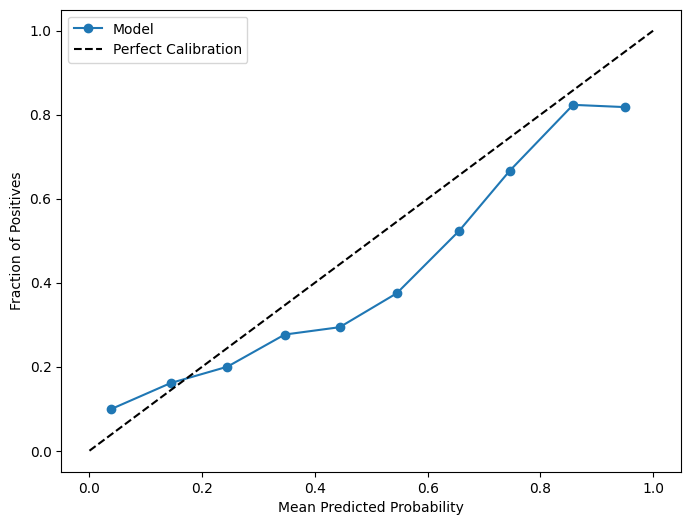

Fraction of Positive: [0.09915612 0.16111111 0.2        0.27659574 0.29411765 0.375
 0.52380952 0.66666667 0.82352941 0.81818182]
Mean Predictive Values: [0.03850066 0.14402658 0.24464189 0.34641729 0.44390776 0.54533597
 0.65607385 0.74571509 0.8580778  0.94932739]
Model saved.


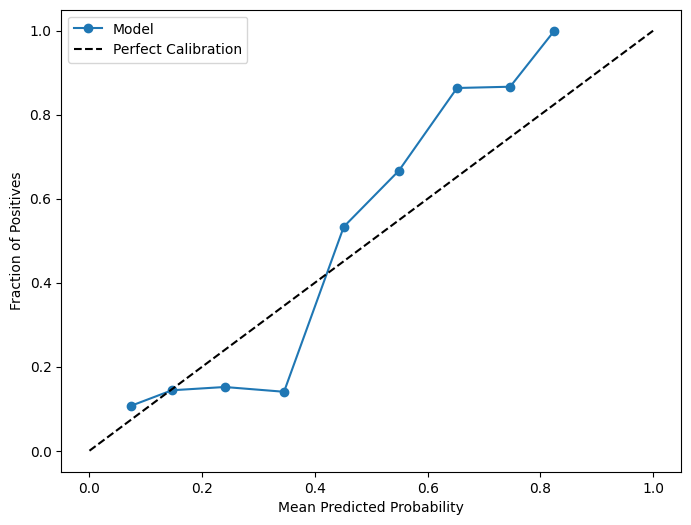

Fraction of Positive: [0.10729614 0.1439206  0.15172414 0.14035088 0.53333333 0.66666667
 0.86363636 0.86666667 1.        ]
Mean Predictive Values: [0.07442413 0.14631724 0.23997472 0.34519917 0.45126259 0.54890174
 0.65214929 0.74639508 0.82480465]


In [3]:
# 04. Logistic Regression Pipeline - V4 - Date and Value columns transformed
#                                   - Priced_By feature transformed
#                                   - Use TimeSeriesSplit to handle the Date_Year feature      
# =======================================================================

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit
from joblib import dump

# ================================================================
# Custom Date Feature Engineering
# ================================================================
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
       
        month = X[self.date_column].dt.month
        dow = X[self.date_column].dt.dayofweek
        quarter = X[self.date_column].dt.quarter

        X["quarter_sin"] = np.sin(2*np.pi*quarter/4)
        X["quarter_cos"] = np.cos(2*np.pi*quarter/4)

        X["month_sin"] = np.sin(2*np.pi*month/12)
        X["month_cos"] = np.cos(2*np.pi*month/12)

        X["dayofweek_sin"] = np.sin(2*np.pi*dow/7)
        X["dayofweek_cos"] = np.cos(2*np.pi*dow/7)

        X.drop(columns=self.date_column, inplace=True)
        return X

# ================================================================
# Numeric Feature Engineering
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        # Reduce skewness
        X["Value"] = np.log1p(X["Value"])
        return X

# ================================================================
# Estimator Feature Engineering
# ================================================================
class EstimatorFeatureTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, column="Priced_By"):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Number of estimators
        X["EstimatorCount"] = (
            X[self.column]
            .str.split("/")
            .apply(len)
        )

        # If the value is "MISSING", treat it as 0 estimators
        X.loc[
            X[self.column].str.upper() == "MISSING",
            "EstimatorCount"
        ] = 0

        X["EstimatorCount"] = X["EstimatorCount"].astype(int)

        # Multiple estimator flag
        X["MultipleEstimators"] = (
            X["EstimatorCount"] > 1
        ).astype(int)

        # Missing Estimator flag
        X["EstimatorMissing"] = (
            X[self.column]
            .str.upper()
            .eq("MISSING")
        ).astype(int)

        return X

# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other",
    "DateMissing",
    "MultipleEstimators",
    "EstimatorMissing"
]

numeric_features = [
    "Value",
    "No_Wall_Types",
    "Date_Year",
    "EstimatorCount"
]

categorical_features = [
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean"
]

cyclical_features = [
    "month_sin",
    "month_cos",
    "dayofweek_sin",
    "dayofweek_cos", 
    "quarter_sin", 
    "quarter_cos"
]

# ================================================================
# Raw Features ONLY
# ================================================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

target = "Success"

# ================================================================
# Train Test Split
# ================================================================
# Sort the Date
quotation_data_df["Date"] = pd.to_datetime(
    quotation_data_df["Date"],
    errors="coerce"
)

quotation_data_df = (
    quotation_data_df
    .sort_values("Date")
    .reset_index(drop=True)
)

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

tscv = TimeSeriesSplit(n_splits=5)

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

# ================================================================
# Preprocessing
# ================================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features),
        ("cycle", "passthrough", cyclical_features)
    ]
)

# ================================================================
# Logistic Regression Pipeline
# ================================================================
logistic_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("estimator_features", EstimatorFeatureTransformer(
            column="Priced_By"
        )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# ================================================================
# Hyperparameter Search
# ================================================================
param_grid = {
    "classifier__C": np.logspace(-5, 5, 21),
    "classifier__solver": ["lbfgs","liblinear"],
    "classifier__penalty": ["l2"],
    "classifier__class_weight": [None,"balanced"]
}

grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

# ================================================================
# Train
# ================================================================
grid_search.fit(X_train, y_train)

print("\nBest Parameters")
print(grid_search.best_params_)

print(f"\nBest CV Balanced Accuracy : {grid_search.best_score_:.4f}")

lgr_best_model_v3 = grid_search.best_estimator_
# 1. Generate predictions from your latest model execution
y_pred = lgr_best_model_v3.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)

from sklearn.metrics import roc_auc_score, precision_recall_curve
from sklearn.calibration import calibration_curve

y_proba = lgr_best_model_v3.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc_roc:.4f}")

avg_precision = average_precision_score(y_test, y_proba)
print(f"Average Precision: {avg_precision:.4f}")

# Calibration check
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_proba, n_bins=10)
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))
plt.plot(mean_predicted_value, fraction_of_positives, 'o-', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.show()

print(f"Fraction of Positive: {fraction_of_positives}")
print(f"Mean Predictive Values: {mean_predicted_value}")

# If points fall on diagonal -> Perfect calibration
# Points above diagonal -> Under-predicting (actual > predicted)
# Points below diagonal -> Over-predicting (actual < predicted)

# Save Trained Model
dump(lgr_best_model_v3, "LogisticRegression_V3.joblib")
print("Model saved.")

# Build Calibrator Model
from sklearn.calibration import CalibratedClassifierCV

# 1. Pass the UNTRAINED pipeline and your TimeSeriesSplit
calibrated_pipeline = CalibratedClassifierCV(
    estimator=lgr_best_model_v3, # Unfitted pipeline
    method="sigmoid",
    cv=tscv                     # Reuses your TimeSeriesSplit
)

# 2. Fit on X_train (Internal CV handles fitting base models and calibrator securely)
calibrated_pipeline.fit(X_train, y_train)

# 3. Evaluate cleanly on X_test
y_proba_calibrator = calibrated_pipeline.predict_proba(X_test)[:, 1]

# Calibration check
fraction_of_positives_calibrator, mean_predicted_value_calibrator = calibration_curve(y_test, y_proba_calibrator, n_bins=10)
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))
plt.plot(mean_predicted_value_calibrator, fraction_of_positives_calibrator, 'o-', label='Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.show()

print(f"Fraction of Positive: {fraction_of_positives_calibrator}")
print(f"Mean Predictive Values: {mean_predicted_value_calibrator}")





Training Samples : 3696
Testing Samples  : 924
Fitting 5 folds for each of 84 candidates, totalling 420 fits

Best Parameters:
{'classifier__C': np.float64(3.1622776601683795), 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

📊 Final Calibrated Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.85      0.98      0.91       749
  Profit (1)       0.80      0.27      0.41       175

    accuracy                           0.85       924
   macro avg       0.83      0.63      0.66       924
weighted avg       0.84      0.85      0.82       924

AUC-ROC Score         : 0.6934
Average Precision     : 0.4935
Raw Brier Score       : 0.1317
Calibrated Brier Score: 0.1303 (Lower is better)


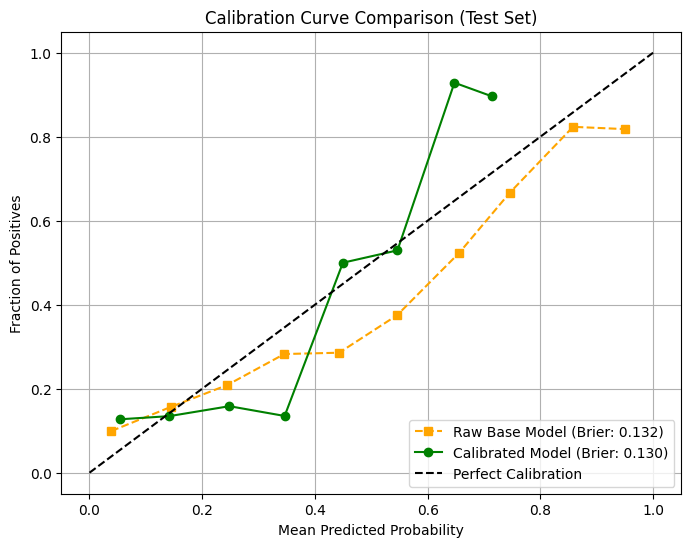

Calibrated model successfully saved.


In [ ]:
# 05. Logistic Regression Pipeline - V5 - Fully Calibrated & Streamlined
#                                       - Use CalibratedClassifierCV
# =======================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import dump

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score, brier_score_loss

# ================================================================
# Single Feature Engineering Transformer
# (Avoids ColumnTransformer KeyError and handles String splits safely)
# ================================================================
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, date_col="Date", priced_by_col="Priced_By", value_col="Value"):
        self.date_col = date_col
        self.priced_by_col = priced_by_col
        self.value_col = value_col

    def fit(self, X, y=None):
        dates = pd.to_datetime(X[self.date_col], errors="coerce")
        self.median_date_ = dates.dropna().median()
        if pd.isna(self.median_date_):
            self.median_date_ = pd.Timestamp("2025-01-01")
        return self

    def transform(self, X):
        X = X.copy()

        # 1. Date Features
        dates = pd.to_datetime(X[self.date_col], errors="coerce")
        X["DateMissing"] = dates.isna().astype(int)
        dates = dates.fillna(self.median_date_)

        X["Date_Year"] = dates.dt.year
        month = dates.dt.month
        dow = dates.dt.dayofweek
        quarter = dates.dt.quarter

        X["quarter_sin"] = np.sin(2 * np.pi * quarter / 4)
        X["quarter_cos"] = np.cos(2 * np.pi * quarter / 4)
        X["month_sin"] = np.sin(2 * np.pi * month / 12)
        X["month_cos"] = np.cos(2 * np.pi * month / 12)
        X["dayofweek_sin"] = np.sin(2 * np.pi * dow / 7)
        X["dayofweek_cos"] = np.cos(2 * np.pi * dow / 7)

        # 2. Value Features
        X[self.value_col] = np.log1p(pd.to_numeric(X[self.value_col], errors="coerce").fillna(0))

        # 3. Estimator Features
        priced_by_str = X[self.priced_by_col].astype(str).str.upper()
        X["EstimatorCount"] = X[self.priced_by_col].astype(str).apply(
            lambda x: len(x.split("/")) if x.strip() and x.upper() != "MISSING" else 0
        )
        X["MultipleEstimators"] = (X["EstimatorCount"] > 1).astype(int)
        X["EstimatorMissing"] = priced_by_str.eq("MISSING").astype(int)

        X.drop(columns=[self.date_col], inplace=True)
        return X

# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW", "RC_Pile", "Steel_Beam", "Sheetpile", "Anchor", "Block",
    "Shotcrete", "Capping_Beam", "Earthwork", "Concrete_Slab", "Precast",
    "Culvert", "Slip_Repair", "Soil_Nail", "Rock_RW", "Bridge", "Concrete",
    "Design_and_Build", "Budget", "Drill_Only", "Labour_Only",
    "Driven_Pile", "Palisade", "Boardwalk", "Soldier", "Insitu",
    "Barrier", "Noise_RW", "Base", "Casing", "Crib",
    "DayWork", "Flood_Repair", "Micro_Pile", "Reno",
    "Temp_RW", "Other",
    "DateMissing", "MultipleEstimators", "EstimatorMissing"
]

numeric_features = ["Value", "No_Wall_Types", "Date_Year", "EstimatorCount"]
categorical_features = ["Priced_By", "Suburb", "Client_Clean"]
cyclical_features = ["month_sin", "month_cos", "dayofweek_sin", "dayofweek_cos", "quarter_sin", "quarter_cos"]

raw_features = [
    "Date", "Value", "No_Wall_Types", "Priced_By", "Suburb", "Client_Clean",
    "Timber_RW", "RC_Pile", "Steel_Beam", "Sheetpile", "Anchor", "Block",
    "Shotcrete", "Capping_Beam", "Earthwork", "Concrete_Slab", "Precast",
    "Culvert", "Slip_Repair", "Soil_Nail", "Rock_RW", "Bridge", "Concrete",
    "Design_and_Build", "Budget", "Drill_Only", "Labour_Only",
    "Driven_Pile", "Palisade", "Boardwalk", "Soldier", "Insitu",
    "Barrier", "Noise_RW", "Base", "Casing", "Crib",
    "DayWork", "Flood_Repair", "Micro_Pile", "Reno",
    "Temp_RW", "Other"
]

target = "Success"

# ================================================================
# Train Test Split
# ================================================================
quotation_data_df["Date"] = pd.to_datetime(quotation_data_df["Date"], errors="coerce")
quotation_data_df = quotation_data_df.sort_values("Date").reset_index(drop=True)

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

tscv = TimeSeriesSplit(n_splits=5)

split_index = int(len(X) * 0.80)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

# ================================================================
# Preprocessing Engine
# ================================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features),
        ("bin", "passthrough", binary_features),
        ("cycle", "passthrough", cyclical_features)
    ]
)

# ================================================================
# Step 1: Optimize Base Model Hyperparameters with GridSearchCV
# ================================================================
base_pipeline = Pipeline([
    ("engineering", FeatureEngineer()),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000, random_state=42))
])

param_grid = {
    "classifier__C": np.logspace(-5, 5, 21),
    "classifier__solver": ["lbfgs", "liblinear"],
    "classifier__penalty": ["l2"],
    "classifier__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

# Extract best hyperparameters to pass into our calibrated pipeline
best_params = grid_search.best_params_

# ================================================================
# Step 2: Fit Calibrated Model using Out-Of-Fold Cross-Validation
# ================================================================
# Re-instantiate an un-fitted base pipeline with optimal hyper-parameters
unfitted_best_pipeline = Pipeline([
    ("engineering", FeatureEngineer()),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=5000,
        random_state=42,
        C=best_params["classifier__C"],
        solver=best_params["classifier__solver"],
        penalty=best_params["classifier__penalty"],
        class_weight=best_params["classifier__class_weight"]
    ))
])

# CalibratedClassifierCV wraps the pipeline and uses TimeSeriesSplit out-of-fold predictions
calibrated_model = CalibratedClassifierCV(
    estimator=unfitted_best_pipeline,
    method="isotonic",
    cv=tscv
)

calibrated_model.fit(X_train, y_train)

# ================================================================
# Step 3: Evaluation on Unseen Test Data
# ================================================================
# Get predictions from base (uncalibrated) best model vs. calibrated model
uncalibrated_model = grid_search.best_estimator_

y_proba_raw = uncalibrated_model.predict_proba(X_test)[:, 1]
y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_cal = calibrated_model.predict(X_test)

print("\n📊 Final Calibrated Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_cal, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)

brier_raw = brier_score_loss(y_test, y_proba_raw)
brier_cal = brier_score_loss(y_test, y_proba_cal)

print(f"AUC-ROC Score         : {roc_auc_score(y_test, y_proba_cal):.4f}")
print(f"Average Precision     : {average_precision_score(y_test, y_proba_cal):.4f}")
print(f"Raw Brier Score       : {brier_raw:.4f}")
print(f"Calibrated Brier Score: {brier_cal:.4f} (Lower is better)")

# ================================================================
# Step 4: Side-by-Side Calibration Comparison Plot
# ================================================================
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, y_proba_raw, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(mean_pred_raw, frac_pos_raw, 's--', label=f'Raw Base Model (Brier: {brier_raw:.3f})', color='orange')
plt.plot(mean_pred_cal, frac_pos_cal, 'o-', label=f'Calibrated Model (Brier: {brier_cal:.3f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve Comparison (Test Set)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Save the final Calibrated Pipeline
dump(calibrated_model, "LogisticRegression_Calibrated_V4.joblib")
print("Calibrated model successfully saved.")

Training Samples   (60%): 2772
Validation Samples (20%): 924
Testing Samples    (20%): 924
Fitting 5 folds for each of 84 candidates, totalling 420 fits

Best Parameters:
{'classifier__C': np.float64(1.0), 'classifier__class_weight': None, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}


c:\Users\Phong\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



📊 Final Calibrated Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.85      0.99      0.92       749
  Profit (1)       0.88      0.25      0.38       175

    accuracy                           0.85       924
   macro avg       0.86      0.62      0.65       924
weighted avg       0.85      0.85      0.81       924

AUC-ROC Score         : 0.6918
Average Precision     : 0.4843
Raw Brier Score       : 0.1356
Calibrated Brier Score: 0.1278 (Lower is better)


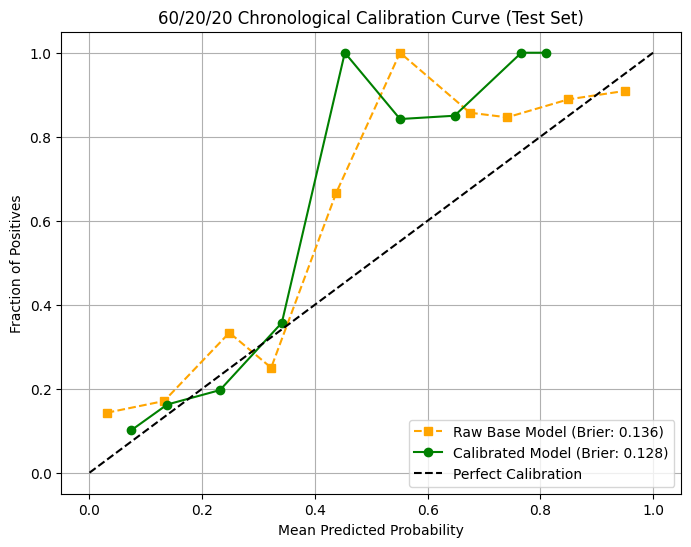

Model saved successfully.


In [9]:
# 06. Logistic Regression Pipeline - V6 - 60/20/20 Chronological Calibration
# =======================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import dump

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score, brier_score_loss

# ================================================================
# Single Feature Engineering Transformer
# ================================================================
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, date_col="Date", priced_by_col="Priced_By", value_col="Value"):
        self.date_col = date_col
        self.priced_by_col = priced_by_col
        self.value_col = value_col

    def fit(self, X, y=None):
        dates = pd.to_datetime(X[self.date_col], errors="coerce")
        self.median_date_ = dates.dropna().median()
        if pd.isna(self.median_date_):
            self.median_date_ = pd.Timestamp("2025-01-01")
        return self

    def transform(self, X):
        X = X.copy()

        # 1. Date Features
        dates = pd.to_datetime(X[self.date_col], errors="coerce")
        X["DateMissing"] = dates.isna().astype(int)
        dates = dates.fillna(self.median_date_)

        X["Date_Year"] = dates.dt.year
        month = dates.dt.month
        dow = dates.dt.dayofweek
        quarter = dates.dt.quarter

        X["quarter_sin"] = np.sin(2 * np.pi * quarter / 4)
        X["quarter_cos"] = np.cos(2 * np.pi * quarter / 4)
        X["month_sin"] = np.sin(2 * np.pi * month / 12)
        X["month_cos"] = np.cos(2 * np.pi * month / 12)
        X["dayofweek_sin"] = np.sin(2 * np.pi * dow / 7)
        X["dayofweek_cos"] = np.cos(2 * np.pi * dow / 7)

        # 2. Value Features
        X[self.value_col] = np.log1p(pd.to_numeric(X[self.value_col], errors="coerce").fillna(0))

        # 3. Estimator Features
        priced_by_str = X[self.priced_by_col].astype(str).str.upper()
        X["EstimatorCount"] = X[self.priced_by_col].astype(str).apply(
            lambda x: len(x.split("/")) if x.strip() and x.upper() != "MISSING" else 0
        )
        X["MultipleEstimators"] = (X["EstimatorCount"] > 1).astype(int)
        X["EstimatorMissing"] = priced_by_str.eq("MISSING").astype(int)

        X.drop(columns=[self.date_col], inplace=True)
        return X

# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW", "RC_Pile", "Steel_Beam", "Sheetpile", "Anchor", "Block",
    "Shotcrete", "Capping_Beam", "Earthwork", "Concrete_Slab", "Precast",
    "Culvert", "Slip_Repair", "Soil_Nail", "Rock_RW", "Bridge", "Concrete",
    "Design_and_Build", "Budget", "Drill_Only", "Labour_Only",
    "Driven_Pile", "Palisade", "Boardwalk", "Soldier", "Insitu",
    "Barrier", "Noise_RW", "Base", "Casing", "Crib",
    "DayWork", "Flood_Repair", "Micro_Pile", "Reno",
    "Temp_RW", "Other",
    "DateMissing", "MultipleEstimators", "EstimatorMissing"
]

numeric_features = ["Value", "No_Wall_Types", "Date_Year", "EstimatorCount"]
categorical_features = ["Priced_By", "Suburb", "Client_Clean"]
cyclical_features = ["month_sin", "month_cos", "dayofweek_sin", "dayofweek_cos", "quarter_sin", "quarter_cos"]

raw_features = [
    "Date", "Value", "No_Wall_Types", "Priced_By", "Suburb", "Client_Clean",
    "Timber_RW", "RC_Pile", "Steel_Beam", "Sheetpile", "Anchor", "Block",
    "Shotcrete", "Capping_Beam", "Earthwork", "Concrete_Slab", "Precast",
    "Culvert", "Slip_Repair", "Soil_Nail", "Rock_RW", "Bridge", "Concrete",
    "Design_and_Build", "Budget", "Drill_Only", "Labour_Only",
    "Driven_Pile", "Palisade", "Boardwalk", "Soldier", "Insitu",
    "Barrier", "Noise_RW", "Base", "Casing", "Crib",
    "DayWork", "Flood_Repair", "Micro_Pile", "Reno",
    "Temp_RW", "Other"
]

target = "Success"

# ================================================================
# Train / Validation / Test Split (60 / 20 / 20)
# ================================================================
quotation_data_df["Date"] = pd.to_datetime(quotation_data_df["Date"], errors="coerce")
quotation_data_df = quotation_data_df.sort_values("Date").reset_index(drop=True)

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

train_idx = int(len(X) * 0.60)
val_idx   = int(len(X) * 0.80)

X_train, y_train = X.iloc[:train_idx], y.iloc[:train_idx]
X_val,   y_val   = X.iloc[train_idx:val_idx], y.iloc[train_idx:val_idx]
X_test,  y_test  = X.iloc[val_idx:], y.iloc[val_idx:]

print(f"Training Samples   (60%): {len(X_train)}")
print(f"Validation Samples (20%): {len(X_val)}")
print(f"Testing Samples    (20%): {len(X_test)}")

# ================================================================
# Preprocessing Engine
# ================================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features),
        ("bin", "passthrough", binary_features),
        ("cycle", "passthrough", cyclical_features)
    ]
)

base_pipeline = Pipeline([
    ("engineering", FeatureEngineer()),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000, random_state=42))
])

# ================================================================
# Step 1: Hyperparameter Search on 60% Training Data
# ================================================================
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "classifier__C": np.logspace(-5, 5, 21),
    "classifier__solver": ["lbfgs", "liblinear"],
    "classifier__penalty": ["l2"],
    "classifier__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=base_pipeline,
    param_grid=param_grid,
    cv=tscv,
    scoring="balanced_accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

# Base model tuned on 60% data
uncalibrated_model = grid_search.best_estimator_

# ================================================================
# Step 2: Fit Calibrated Model on 20% Validation Data (cv="prefit")
# ================================================================
# Clone best estimator structure so weights fit cleanly on X_train
base_model_fitted = clone(uncalibrated_model)
base_model_fitted.fit(X_train, y_train)

# Fit calibrator on contiguous X_val block
calibrated_model = CalibratedClassifierCV(
    estimator=base_model_fitted,
    method="sigmoid", # Use "isotonic" if sigmoid still produces distortions
    cv="prefit"       # Uses clean X_val without fold distortion
)

calibrated_model.fit(X_val, y_val)

# ================================================================
# Step 3: Final Evaluation on 20% Unseen Test Set
# ================================================================
y_proba_raw = uncalibrated_model.predict_proba(X_test)[:, 1]
y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_cal = calibrated_model.predict(X_test)

print("\n📊 Final Calibrated Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred_cal, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)

brier_raw = brier_score_loss(y_test, y_proba_raw)
brier_cal = brier_score_loss(y_test, y_proba_cal)

print(f"AUC-ROC Score         : {roc_auc_score(y_test, y_proba_cal):.4f}")
print(f"Average Precision     : {average_precision_score(y_test, y_proba_cal):.4f}")
print(f"Raw Brier Score       : {brier_raw:.4f}")
print(f"Calibrated Brier Score: {brier_cal:.4f} (Lower is better)")

# ================================================================
# Step 4: Calibration Comparison Plot
# ================================================================
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, y_proba_raw, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(mean_pred_raw, frac_pos_raw, 's--', label=f'Raw Base Model (Brier: {brier_raw:.3f})', color='orange')
plt.plot(mean_pred_cal, frac_pos_cal, 'o-', label=f'Calibrated Model (Brier: {brier_cal:.3f})', color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('60/20/20 Chronological Calibration Curve (Test Set)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Save final calibrated model
dump(calibrated_model, "LogisticRegression_Calibrated_602020.joblib")
print("Model saved successfully.")

In [20]:
# Feature Importance (Logistic Regression Coefficients)
# ================================================================

# Get the fitted preprocessor
preprocessor = lgr_best_model_v3.named_steps["preprocessor"]

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Get coefficients
coefficients = lgr_best_model_v3.named_steps["classifier"].coef_[0]

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    'Odds_Ratio': np.exp(coefficients),
    "AbsCoefficient": np.abs(coefficients)
})

# Sort by absolute importance
feature_importance = feature_importance.sort_values(
    by="AbsCoefficient",
    ascending=False
)

print("\nTop 30 Most Important Features")
print("=" * 80)
print(feature_importance.head(30))
print("=" * 80)


Top 30 Most Important Features
                                     Feature  Coefficient  Odds_Ratio  \
944                             bin__DayWork     3.422995   30.661116   
648        cat__Client_Clean_naturalhabitats     2.745246   15.568448   
116                    cat__Suburb_mahurangi     2.679560   14.578681   
555                 cat__Client_Clean_ldeltd     2.483079   11.978087   
11                     cat__Priced_By_EGIDIO    -2.469577    0.084621   
265        cat__Client_Clean_aucklandcouncil     2.468973   11.810314   
245                cat__Client_Clean_airdale     2.447907   11.564113   
281               cat__Client_Clean_bobhicks     2.442654   11.503527   
539             cat__Client_Clean_kerrydines     2.434587   11.411107   
342          cat__Client_Clean_civilsolution     2.406138   11.091045   
244           cat__Client_Clean_aintreegroup     2.390523   10.919199   
471            cat__Client_Clean_grantletica     2.362402   10.616418   
373           cat__

In [35]:
# 05. Decision Tree Pipeline - V1   - Date and Value columns transformed - Integer only
#                                   - Priced_By feature transformed
#                                   - Use TimeSeriesSplit to handle the Date_Year feature      
# =======================================================================

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit

# ================================================================
# Custom Date Feature Engineering
# ================================================================
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
        X["Date_Quarter"] = X[self.date_column].dt.quarter
        X["Date_Month"] = X[self.date_column].dt.month
        X["Date_DayOfWeek"] = X[self.date_column].dt.dayofweek

        X.drop(columns=self.date_column, inplace=True)
        return X

# ================================================================
# Numeric Feature Engineering
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.median_value_ = X["Value"].median()
        return self
    
    def transform(self, X):
        X = X.copy()
        X["Value"] = X["Value"].fillna(self.median_value_)
        X["Value"] = np.log1p(X["Value"])
        return X

# ================================================================
# Estimator Feature Engineering
# ================================================================
class EstimatorFeatureTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, column="Priced_By"):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Number of estimators
        X["EstimatorCount"] = (
            X[self.column]
            .str.split("/")
            .apply(len)
        )

        # If the value is "MISSING", treat it as 0 estimators
        X.loc[
            X[self.column].str.upper() == "MISSING",
            "EstimatorCount"
        ] = 0

        X["EstimatorCount"] = X["EstimatorCount"].astype(int)

        # Missing Estimator flag
        X["EstimatorMissing"] = (
            X[self.column]
            .str.upper()
            .eq("MISSING")
        ).astype(int)

        return X

# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other",
    "DateMissing",
    # "MultipleEstimators",
    "EstimatorMissing"
]

numeric_features = [
    "Value",
    "No_Wall_Types",
    "Date_Year",
    "Date_Month",
    "Date_Quarter",
    "Date_DayOfWeek",
    "EstimatorCount"
]

categorical_features = [
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean"
]

# ================================================================
# Raw Features ONLY
# ================================================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    # "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

target = "Success"

# ================================================================
# Train Test Split
# ================================================================
# Sort the Date
quotation_data_df["Date"] = pd.to_datetime(
    quotation_data_df["Date"],
    errors="coerce"
)

quotation_data_df = (
    quotation_data_df
    .sort_values("Date")
    .reset_index(drop=True)
)

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

tscv = TimeSeriesSplit(n_splits=5)

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

# ================================================================
# Preprocessing
# ================================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
    # ("scaler", StandardScaler()) dont need scaling for tree based model
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features)
    ]
)

# ================================================================
# Decision Tree Pipeline
# ================================================================
decision_tree_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("estimator_features", EstimatorFeatureTransformer(
            column="Priced_By"
        )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

# ================================================================
# Hyperparameter Search
# ================================================================
param_grid = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 3, 5, 7, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10, 20, 50],
    "classifier__min_samples_leaf": [1, 2, 5, 10, 20],
    "classifier__max_features": [None, "sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"],
    "classifier__ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01]
}

random_search = RandomizedSearchCV(
    estimator=decision_tree_pipeline,
    param_distributions=param_grid,
    n_iter=150,
    cv=tscv,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# ================================================================
# Train
# ================================================================
random_search.fit(X_train, y_train)

print("\nBest Parameters")
print(random_search.best_params_)

print(f"\nBest CV Balanced Accuracy : {random_search.best_score_:.4f}")

rt_best_model_v1 = random_search.best_estimator_
# 1. Generate predictions from your latest model execution
y_pred = rt_best_model_v1.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)

from sklearn.metrics import roc_auc_score, precision_recall_curve
from sklearn.calibration import calibration_curve

y_proba = rt_best_model_v1.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc_roc:.4f}")

# 3. Feature Importance
feature_names = rt_best_model_v1.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rt_best_model_v1.named_steps[
        "classifier"
    ].feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)
print(importance.head(30))

# Save Trained Model
from joblib import dump

dump(rt_best_model_v1, "RandomTreeClassification_V1.joblib")

print("Model saved.")


Training Samples : 3696
Testing Samples  : 924
Fitting 5 folds for each of 150 candidates, totalling 750 fits

Best Parameters
{'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 1, 'classifier__max_features': None, 'classifier__max_depth': 7, 'classifier__criterion': 'gini', 'classifier__class_weight': 'balanced', 'classifier__ccp_alpha': 0.001}

Best CV Balanced Accuracy : 0.6727

📊 Final Model Classification Report:
              precision    recall  f1-score   support

    Loss (0)       0.83      0.89      0.86       749
  Profit (1)       0.31      0.22      0.25       175

    accuracy                           0.76       924
   macro avg       0.57      0.55      0.56       924
weighted avg       0.73      0.76      0.74       924

AUC-ROC: 0.6923
                           Feature  Importance
2                   num__Date_Year    0.603587
950          bin__EstimatorMissing    0.221761
0                       num__Value    0.034403
914                bin__Stee

In [ ]:
# 06. Decision Tree Pipeline - V2   - Date and Value columns transformed - Integer only
#                     - Priced_By feature transformed
#                     - Use TimeSeriesSplit to handle the Date_Year feature      
# =======================================================================

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import TimeSeriesSplit

# ================================================================
# Custom Date Feature Engineering
# ================================================================
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, date_column="Date"):
        self.date_column = date_column

    def fit(self, X, y=None):
        dates = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )
        self.median_date_ = dates.dropna().median()
        return self

    def transform(self, X):
        X = X.copy()
        X[self.date_column] = pd.to_datetime(
            X[self.date_column],
            errors="coerce"
        )

        # Missing Indicator
        X["DateMissing"] = X[self.date_column].isna().astype(int)

        # Median Imputation
        X[self.date_column] = X[self.date_column].fillna(
            self.median_date_
        )

        # Date Features
        X["Date_Year"] = X[self.date_column].dt.year
        X["Date_Month"] = X[self.date_column].dt.month
        X["Date_DayOfWeek"] = X[self.date_column].dt.dayofweek

        X.drop(columns=self.date_column, inplace=True)
        return X

# ================================================================
# Numeric Feature Engineering
# ================================================================
class NumericFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.median_value_ = X["Value"].median()
        return self
    
    def transform(self, X):
        X = X.copy()
        X["Value"] = X["Value"].fillna(self.median_value_)
        X["Value"] = np.log1p(X["Value"])
        return X

# ================================================================
# Estimator Feature Engineering
# ================================================================
class EstimatorFeatureTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, column="Priced_By"):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Number of estimators
        X["EstimatorCount"] = (
            X[self.column]
            .str.split("/")
            .apply(len)
        )

        # If the value is "MISSING", treat it as 0 estimators
        X.loc[
            X[self.column].str.upper() == "MISSING",
            "EstimatorCount"
        ] = 0

        X["EstimatorCount"] = X["EstimatorCount"].astype(int)

        # Missing Estimator flag
        X["EstimatorMissing"] = (
            X[self.column]
            .str.upper()
            .eq("MISSING")
        ).astype(int)

        return X

# ================================================================
# Feature Lists
# ================================================================
binary_features = [
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other",
    "DateMissing",
    # "MultipleEstimators",
    "EstimatorMissing"
]

numeric_features = [
    "Value",
    "No_Wall_Types",
    "Date_Year",
    "Date_Month",
    "Date_DayOfWeek",
    "EstimatorCount"
]

categorical_features = [
    "Priced_By",
    "Contact_Clean",
    "Suburb",
    "Client_Clean"
]

# ================================================================
# Raw Features ONLY
# ================================================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

target = "Success"

# ================================================================
# Train Test Split
# ================================================================
# Sort the Date
quotation_data_df["Date"] = pd.to_datetime(
    quotation_data_df["Date"],
    errors="coerce"
)

quotation_data_df = (
    quotation_data_df
    .sort_values("Date")
    .reset_index(drop=True)
)

X = quotation_data_df[raw_features]
y = quotation_data_df[target]

tscv = TimeSeriesSplit(n_splits=5)

split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples  : {len(X_test)}")

# ================================================================
# Preprocessing
# ================================================================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
    # ("scaler", StandardScaler()) dont need scaling for tree based model
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bin", "passthrough", binary_features)
    ]
)

# ================================================================
# Decision Tree Pipeline
# ================================================================
decision_tree_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("estimator_features", EstimatorFeatureTransformer(
            column="Priced_By"
        )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

# ================================================================
# Hyperparameter Search
# ================================================================
param_grid = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 3, 5, 7, 10, 15, 20],
    "classifier__min_samples_split": [2, 5, 10, 20, 50],
    "classifier__min_samples_leaf": [1, 2, 5, 10, 20],
    "classifier__max_features": [None, "sqrt", "log2"],
    "classifier__class_weight": [None, "balanced"],
    "classifier__ccp_alpha": [0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01]
}

random_search = RandomizedSearchCV(
    estimator=decision_tree_pipeline,
    param_distributions=param_grid,
    n_iter=150,
    cv=tscv,
    scoring="balanced_accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# ================================================================
# Train
# ================================================================
random_search.fit(X_train, y_train)

print("\nBest Parameters")
print(random_search.best_params_)

print(f"\nBest CV Balanced Accuracy : {random_search.best_score_:.4f}")

rt_best_model_v1 = random_search.best_estimator_
# 1. Generate predictions from your latest model execution
y_pred = rt_best_model_v1.predict(X_test)

# 2. Extract and print the Classification Report
print("\n📊 Final Model Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Loss (0)', 'Profit (1)']))
print("=" * 60)

from sklearn.metrics import roc_auc_score, precision_recall_curve
from sklearn.calibration import calibration_curve

y_proba = rt_best_model_v1.predict_proba(X_test)[:, 1]
auc_roc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc_roc:.4f}")

# 3. Feature Importance
feature_names = rt_best_model_v1.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rt_best_model_v1.named_steps[
        "classifier"
    ].feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)
print(importance.head(30))

# Save Trained Model
from joblib import dump

dump(rt_best_model_v1, "RandomTreeClassification_V1.joblib")

print("Model saved.")


Training Samples : 3696
Testing Samples  : 924
Fitting 5 folds for each of 150 candidates, totalling 750 fits


In [33]:
quotation_data_df.groupby(
    quotation_data_df["Date"].dt.year
)["Success"].agg(
    Quotes="count",
    WinRate="mean"
)

,Quotes,WinRate
Date,,
2013.0,206,0.310680
2014.0,305,0.285246
2015.0,275,0.287273
2016.0,232,0.323276
2017.0,303,0.303630
2018.0,227,0.325991
2019.0,285,0.298246
2020.0,421,0.249406
2021.0,396,0.310606


Threshold: 0.40

              precision    recall  f1-score   support

    Loss (0)       0.86      0.91      0.89       749
  Profit (1)       0.50      0.39      0.44       175

    accuracy                           0.81       924
   macro avg       0.68      0.65      0.66       924
weighted avg       0.80      0.81      0.80       924

Balanced Accuracy : 0.6496
AUC-ROC           : 0.7442


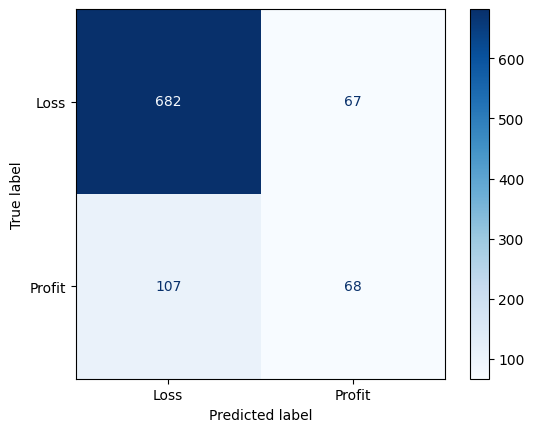

In [25]:
# Custom Threshold
# ==========================================
threshold = 0.40

# Probability of class 1 (Profit)
y_prob = lgr_best_model_v3.predict_proba(X_test)[:, 1]

# Apply custom threshold
y_pred = (y_prob >= threshold).astype(int)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    roc_auc_score
)

print(f"Threshold: {threshold:.2f}\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Loss (0)", "Profit (1)"]
))

print(f"Balanced Accuracy : {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC           : {roc_auc_score(y_test, y_prob):.4f}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Loss", "Profit"],
    cmap="Blues"
)

In [ ]:
# inspect the training performance as well as the test performance.

from sklearn.metrics import balanced_accuracy_score

train_pred = lgr_best_model_v3.predict(X_train)
test_pred = lgr_best_model_v3.predict(X_test)

print(
    "Train:",
    balanced_accuracy_score(y_train, train_pred)
)

print(
    "Test:",
    balanced_accuracy_score(y_test, test_pred)
)

In [ ]:
# Compare the Threshold
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

y_prob = lgr_best_model_v3.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for t in thresholds:

    y_pred = (y_prob >= t).astype(int)

    results.append({
        "Threshold": t,
        "BalancedAccuracy": balanced_accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    })

results = pd.DataFrame(results)

print(results)

In [48]:
# Make Classification Prediction from data file
import pandas as pd
from joblib import load

# ==========================================
# Load trained model
# ==========================================
model = load("LogisticRegression_V3.joblib")

# ==========================================
# Load Excel file
# ==========================================
new_df = pd.read_excel(r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data Test.xlsx")

# ==========================================
# Keep only raw features
# ==========================================
raw_features = [
    "Date",
    "Value",
    "No_Wall_Types",
    "Priced_By",
    "Contact_Clean",
    "Suburb",
    "Client_Clean",
    "Timber_RW","RC_Pile","Steel_Beam","Sheetpile","Anchor","Block",
    "Shotcrete","Capping_Beam","Earthwork","Concrete_Slab","Precast",
    "Culvert","Slip_Repair","Soil_Nail","Rock_RW","Bridge","Concrete",
    "Design_and_Build","Budget","Drill_Only","Labour_Only",
    "Driven_Pile","Palisade","Boardwalk","Soldier","Insitu",
    "Barrier","Noise_RW","Base","Casing","Crib",
    "DayWork","Flood_Repair","Micro_Pile","Reno",
    "Temp_RW","Other"
]

X_new = new_df[raw_features]

# ==========================================
# Predict
# ==========================================
pred_class = model.predict(X_new)

pred_probability = model.predict_proba(X_new)

# Probability of Profit (class=1)
won_probability = pred_probability[:,1]

lost_probability = pred_probability[:,0]

# ==========================================
# Save predictions
# ==========================================
new_df["Prediction"] = pred_class

new_df["Prediction_Label"] = new_df["Prediction"].map({
    0:"Lost",
    1:"Won"
})

new_df["Probability_Won"] = won_probability

new_df["Probability_Lost"] = lost_probability

# ==========================================
# Save Excel
# ==========================================
output_file = r"C:\Users\Phong\Downloads\Quotation Prediction Logistic.csv"

new_df.to_csv(
    output_file,
    index=False
)

print(f"Prediction saved to:\n{output_file}")

Prediction saved to:
C:\Users\Phong\Downloads\Quotation Prediction Logistic.csv


In [ ]:
# Inpect the distribution of grouper
client_counts = quotation_data_df["Client_Clean"].value_counts()

print(client_counts.describe())

print(client_counts.head(20))
print(client_counts.tail(20))


for threshold in [2, 5, 10, 20, 30, 50]:
    kept = (client_counts >= threshold).sum()
    print(f"{threshold:2d}: keep {kept:3d} clients")

In [ ]:
# Save dataframe after trasformation for checking
# 1. Build a preprocessing-only pipeline using your existing objects
debug_pipeline = Pipeline([
    ("date_features", DateFeatureTransformer()),
    ("estimator_features", EstimatorFeatureTransformer(
            column="Priced_By"
        )),
    ("numeric_features", NumericFeatureTransformer()),
    ("preprocessor", preprocessor)
])

# 2. Fit and transform your training data to see the final numeric matrix
X_train_transformed = debug_pipeline.fit_transform(X_train)

# 3. Retrieve the post-one-hot-encoded column names from the preprocessor step
# Note: This requires scikit-learn 1.0 or newer
feature_names = debug_pipeline.named_steps["preprocessor"].get_feature_names_out()

# 4. Reconstruct into a beautiful, readable DataFrame
transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)

# 5. Export locally to a CSV file
transformed_df.to_csv(r"C:\Users\Phong\Downloads\Quotation Data Test.csv", index=False)

print(f"✅ Success! Exported a matrix of {transformed_df.shape[0]} rows and {transformed_df.shape[1]} columns.")
print("Check your local directory for 'transformed_training_data.csv'.")

Generating SHAP Global Summary Plot...


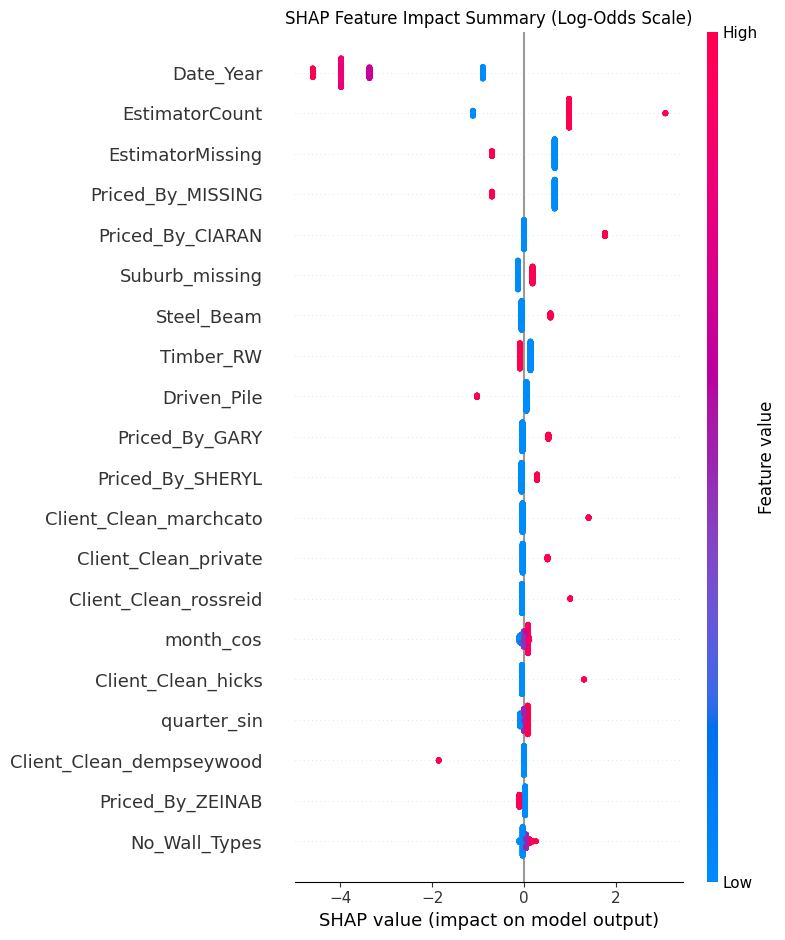


Generating Local Explanation for Test Sample #0...


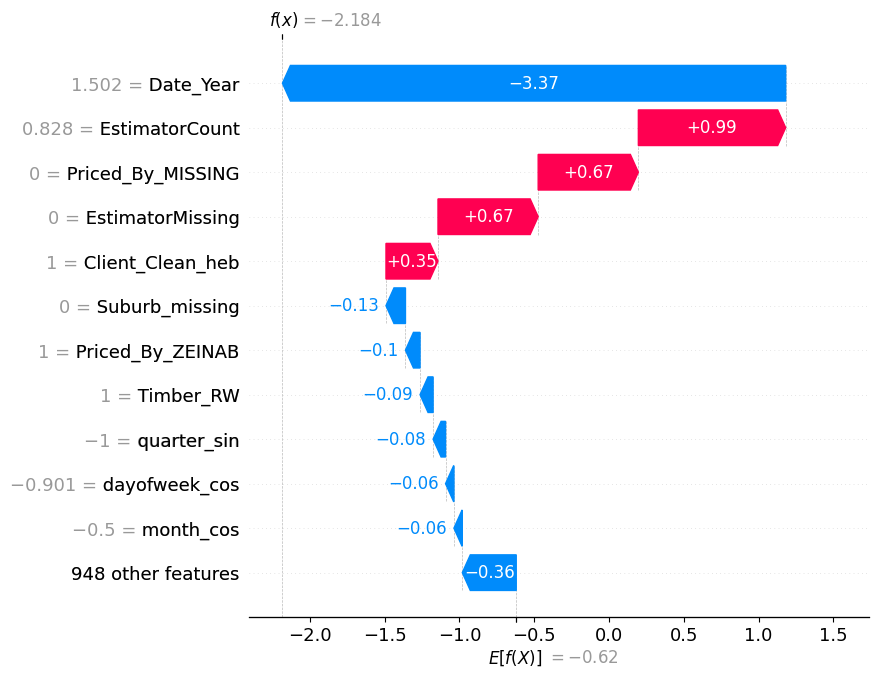

In [ ]:
# SHAP Function (Handles Multi-Step Feature Engineering)
# ================================================================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyze_logistic_shap(lgr_pipeline, X_train, X_test, top_n=20):
    """
    Computes and visualizes SHAP values for a Logistic Regression Pipeline,
    dynamically handling any number of feature engineering steps.
    """
    # 1. Safely retrieve pipeline components: classifier and preprocessor
    # named_steps allow accessing pipeline component by name
    classifier = lgr_pipeline.named_steps['classifier']       # need the classifier for SHAP's explainer
    preprocessor = lgr_pipeline.named_steps['preprocessor']   # need the preprocessor to understand feature transformations
    
    # 2. Sequentially pass data through all transformers before 'preprocessor'
    # pipeline has multiple transformation steps that must be applied in order
    # SHAP needs the FINAL feature matrix that the model actually sees
    X_train_curr = X_train.copy()
    X_test_curr = X_test.copy()

    for step_name, step_obj in lgr_pipeline.steps:
        if step_name == 'preprocessor':
            break
        X_train_curr = step_obj.transform(X_train_curr)
        X_test_curr = step_obj.transform(X_test_curr)

    '''
    # If all Feature Engineering wrapped in one class and named as 'engineering' in Pipeline
    # 1. Access components
    engineering = fitted_pipeline.named_steps['engineering']
    preprocessor = fitted_pipeline.named_steps['preprocessor']
    classifier = fitted_pipeline.named_steps['classifier']

    # 2. Transform raw features through FeatureEngineer & ColumnTransformer
    X_train_engineered = engineering.transform(X_train)
    X_test_engineered = engineering.transform(X_test)

    X_train_trans = preprocessor.transform(X_train_engineered)
    X_test_trans = preprocessor.transform(X_test_engineered)
    '''

    # 3. Pass through ColumnTransformer
    X_train_trans = preprocessor.transform(X_train_curr)
    X_test_trans = preprocessor.transform(X_test_curr)

    # 4. Extract feature names post-ColumnTransformer
    feature_names = []
    for name, trans, cols in preprocessor.transformers_:
        if name == 'num':
            feature_names.extend(cols)
        elif name == 'cat':
            ohe = trans.named_steps['encoder']
            cat_cols = ohe.get_feature_names_out(cols).tolist()
            feature_names.extend(cat_cols)
        elif name in ['bin', 'cycle']:
            feature_names.extend(cols)

    # Convert test array back to DataFrame for cleaner SHAP displays
    X_test_df = pd.DataFrame(X_test_trans, columns=feature_names)
    X_train_df = pd.DataFrame(X_train_trans, columns=feature_names)

    # 5. Initialize LinearExplainer
    # For logistic regression, SHAP values are:
    # SHAP_i = coefficient_i * (feature_i - mean_feature_i)
    # This is much faster than KernelExplainer (which would be very slow)
    explainer = shap.LinearExplainer(classifier, X_train_df)
    shap_values = explainer(X_test_df)

    # 6. Global Summary Plot (Beeswarm Plot)
    print("Generating SHAP Global Summary Plot...")
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_test_df, max_display=top_n, show=False)
    plt.title("SHAP Feature Impact Summary (Log-Odds Scale)", fontsize=12)
    plt.tight_layout()
    plt.show()

    # 7. Single Quote Local Interpretation (Waterfall Plot)
    print("\nGenerating Local Explanation for Test Sample #0...")
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[0], max_display=12)

    return explainer, shap_values, X_test_df

explainer, shap_values, X_test_trans_df = analyze_logistic_shap(lgr_best_model_v3, X_train, X_test)

In [ ]:
# Batch Processing with Separated Driver & Impact Columns
# ================================================================
import pandas as pd
import numpy as np
import shap

def log_odds_to_prob(log_odds):
    """Converts log-odds scale to standard probability [0, 1]."""
    return 1 / (1 + np.exp(-log_odds))

def process_batch_quotes_from_excel(file_path, fitted_pipeline, explainer, output_file="tender_predictions_explained.xlsx"):
    """
    Processes an Excel file of quotes, converts raw SHAP values to percentage 
    probability changes, and exports an enriched Excel report with separate 
    columns for Feature Names and SHAP/% Impacts.
    """
    # 1. Load incoming quotes from Excel
    print(f"📄 Loading new quotes from {file_path}...")
    df_raw = pd.read_excel(file_path)
    df_results = df_raw.copy()

    # 2. Extract pipeline components
    preprocessor = fitted_pipeline.named_steps['preprocessor']

    # 3. Transform batch data sequentially up to ColumnTransformer
    X_curr = df_raw.copy()
    for step_name, step_obj in fitted_pipeline.steps:
        if step_name == 'preprocessor':
            break
        X_curr = step_obj.transform(X_curr)

    X_trans = preprocessor.transform(X_curr)

    # Reconstruct feature names post-encoding
    feature_names = []
    for name, trans, cols in preprocessor.transformers_:
        if name == 'num':
            feature_names.extend(cols)
        elif name == 'cat':
            ohe = trans.named_steps['encoder']
            feature_names.extend(ohe.get_feature_names_out(cols).tolist())
        elif name in ['bin', 'cycle']:
            feature_names.extend(cols)

    X_trans_df = pd.DataFrame(X_trans, columns=feature_names)

    # 4. Predict Win Probabilities
    win_probabilities = fitted_pipeline.predict_proba(df_raw)[:, 1]
    df_results['Predicted_Win_Prob_%'] = np.round(win_probabilities * 100, 1)
    df_results['Predicted_Outcome'] = np.where(win_probabilities >= 0.5, 'WIN', 'LOSS')

    # 5. Compute SHAP Values
    print("⚡ Computing SHAP values and probability impacts...")
    shap_batch = explainer(X_trans_df)

    pos_driver_names = []
    pos_driver_impacts = []
    neg_driver_names = []
    neg_driver_impacts = []

    # 6. Extract Raw SHAP Values and Convert to Percentage Point Impacts (Δp)
    for i in range(len(df_raw)):
        total_log_odds = shap_batch[i].base_values + np.sum(shap_batch[i].values)
        p_final = log_odds_to_prob(total_log_odds)
        
        row_shap_values = shap_batch[i].values
        
        # Calculate impact of each feature by evaluating probability without that feature
        prob_without_feature = log_odds_to_prob(total_log_odds - row_shap_values)
        delta_p_array = (p_final - prob_without_feature) * 100  # Convert to % points

        # Find top positive and negative drivers
        top_pos_idx = np.argmax(delta_p_array)
        top_neg_idx = np.argmin(delta_p_array)

        # Extract names and values
        pos_feature = feature_names[top_pos_idx]
        raw_pos_shap = row_shap_values[top_pos_idx]
        pos_pct = delta_p_array[top_pos_idx]
        
        neg_feature = feature_names[top_neg_idx]
        raw_neg_shap = row_shap_values[top_neg_idx]
        neg_pct = delta_p_array[top_neg_idx]

        # Format positive driver outputs
        if pos_pct > 0:
            pos_driver_names.append(pos_feature)
            pos_driver_impacts.append(f"SHAP: +{raw_pos_shap:.2f} | +{pos_pct:.1f}%")
        else:
            pos_driver_names.append("None")
            pos_driver_impacts.append("N/A")

        # Format negative driver outputs
        if neg_pct < 0:
            neg_driver_names.append(neg_feature)
            neg_driver_impacts.append(f"SHAP: {raw_neg_shap:.2f} | {neg_pct:.1f}%")
        else:
            neg_driver_names.append("None")
            neg_driver_impacts.append("N/A")

    # 7. Add separated columns to output DataFrame
    df_results['Primary_Win_Driver'] = pos_driver_names
    df_results['Win_Driver_Impact'] = pos_driver_impacts
    df_results['Primary_Risk_Driver'] = neg_driver_names
    df_results['Risk_Driver_Impact'] = neg_driver_impacts

    # 8. Export enriched results back to Excel
    df_results.to_excel(output_file, index=False)
    print(f"✅ Exported enriched Excel file to: {output_file}\n")

    return df_results, shap_batch, X_trans_df

'''
 # 6. Extract Raw SHAP Values and Convert to Percentage Point Impacts (Δp)
# Example: A single quote with 3 features

# Step 1: Get SHAP values
base_value = -0.312  # Average log-odds = shap_batch[i].base_values
shap_values = [0.45, -0.23, 0.12]  # Contributions: Value, EstimatorCount, Date_Year
                                   # shap_batch[i].values

# Step 2: Calculate total log-odds 
# --> total_log_odds = shap_batch[i].base_values + np.sum(shap_batch[i].values)
total_log_odds = -0.312 + 0.45 + (-0.23) + 0.12 = 0.028

# Step 3: Convert to probability: p_final = log_odds_to_prob(total_log_odds)
p_final = 1 / (1 + np.exp(-0.028)) = 0.507  # 50.7% chance of profit

# Step 4: Calculate impact of EACH feature
# For Value (SHAP = 0.45):
prob_without_value = 1 / (1 + np.exp(-(0.028 - 0.45)))
                    = 1 / (1 + np.exp(0.422))
                    = 0.396  # 39.6% chance without Value contribution
impact_value = (0.507 - 0.396) * 100 = +11.1 percentage points

# This means: Value increased profit chance by 11.1 percentage points!

# For EstimatorCount (SHAP = -0.23):
prob_without_estimator = 1 / (1 + np.exp(-(0.028 - (-0.23))))
                       = 1 / (1 + np.exp(-0.258))
                       = 0.564  # 56.4% chance without EstimatorCount contribution
impact_estimator = (0.507 - 0.564) * 100 = -5.7 percentage points

# This means: EstimatorCount decreased profit chance by 5.7 percentage points!

# For Date_Year (SHAP = 0.12):
prob_without_date = 1 / (1 + np.exp(-(0.028 - 0.12)))
                  = 1 / (1 + np.exp(0.092))
                  = 0.477  # 47.7% chance without Date_Year contribution
impact_date = (0.507 - 0.477) * 100 = +3.0 percentage points
'''

In [ ]:
# Process all tenders at once
df_explained, shap_batch, X_trans_df = process_batch_quotes_from_excel(
    file_path=r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data Test.xlsx",
    fitted_pipeline=lgr_best_model_v3,
    explainer=explainer
)

📊 Generating Beeswarm Plot for Incoming Batch Tenders...


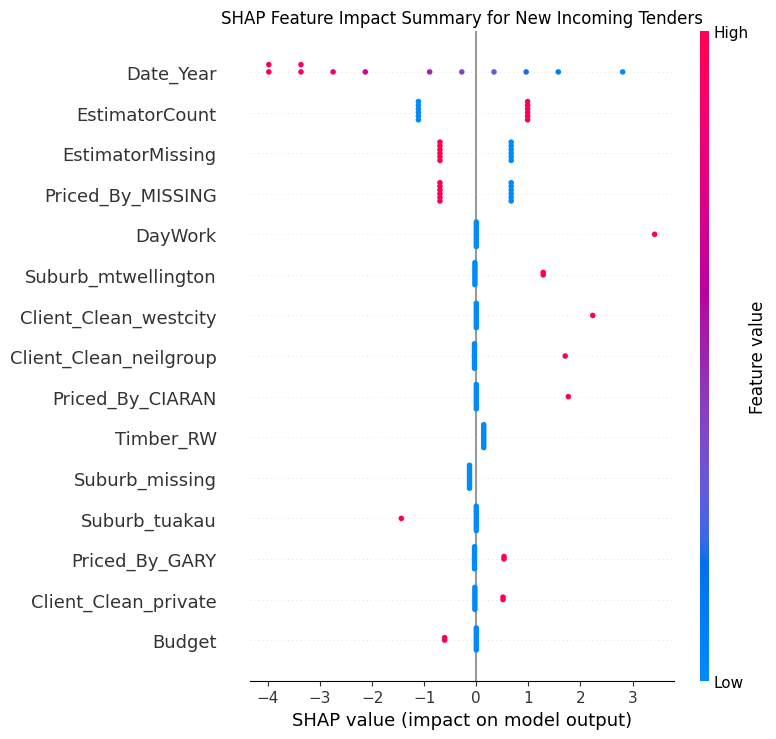


🎯 Generating Waterfall Plot for Tender: Row #2 (Win Prob: 17.3%)...


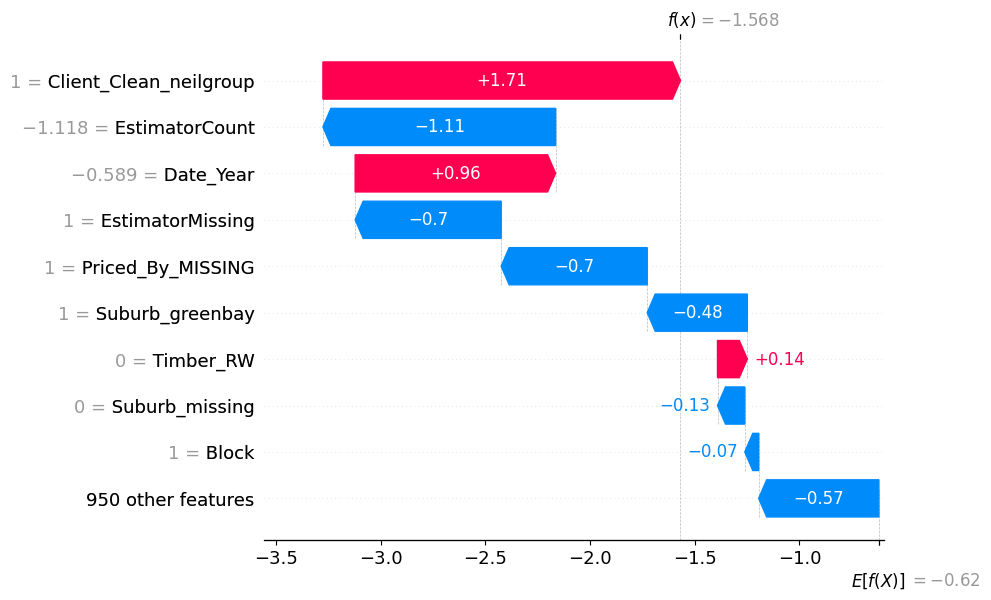

In [38]:
# Plot Beeswarm and Waterfall charts

import matplotlib.pyplot as plt
import shap

# Assume you've already run:
# df_explained, shap_batch, X_trans_df = process_batch_quotes_from_excel(...)

# ================================================================
# 1. BEESWARM PLOT: Batch Portfolio Overview
# ================================================================
print("📊 Generating Beeswarm Plot for Incoming Batch Tenders...")

plt.figure(figsize=(10, 8))
# We pass the full Explanation object for the whole batch
shap.summary_plot(shap_batch, X_trans_df, max_display=15, show=False)
plt.title("SHAP Feature Impact Summary for New Incoming Tenders", fontsize=12)
plt.tight_layout()
plt.show()

# ================================================================
# 2. WATERFALL PLOT: Individual Quote Deep-Dive
# ================================================================
# Choose row index 'i' (e.g., Row 0, Row 1, Row 2) from your Excel file
quote_index = 2  

quote_id = df_explained.iloc[quote_index].get('Quote_ID', f'Row #{quote_index}')
win_prob = df_explained.iloc[quote_index]['Predicted_Win_Prob_%']

print(f"\n🎯 Generating Waterfall Plot for Tender: {quote_id} (Win Prob: {win_prob}%)...")

plt.figure(figsize=(10, 6))
# We slice shap_batch with [quote_index] to select a single row
shap.plots.waterfall(shap_batch[quote_index], max_display=10)